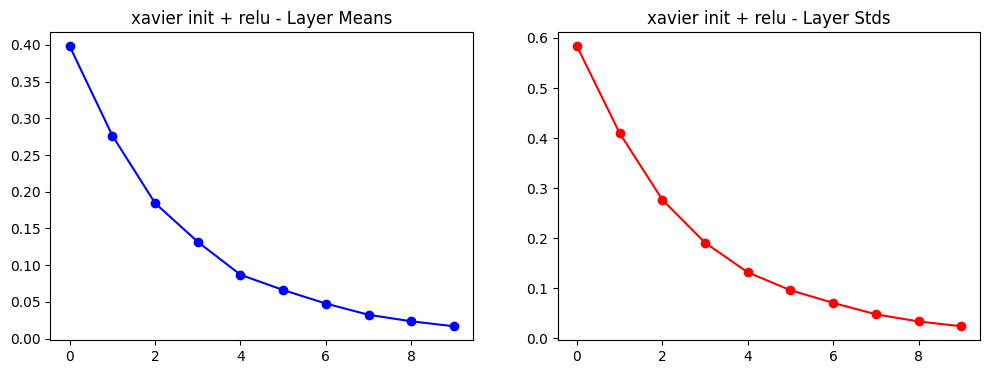

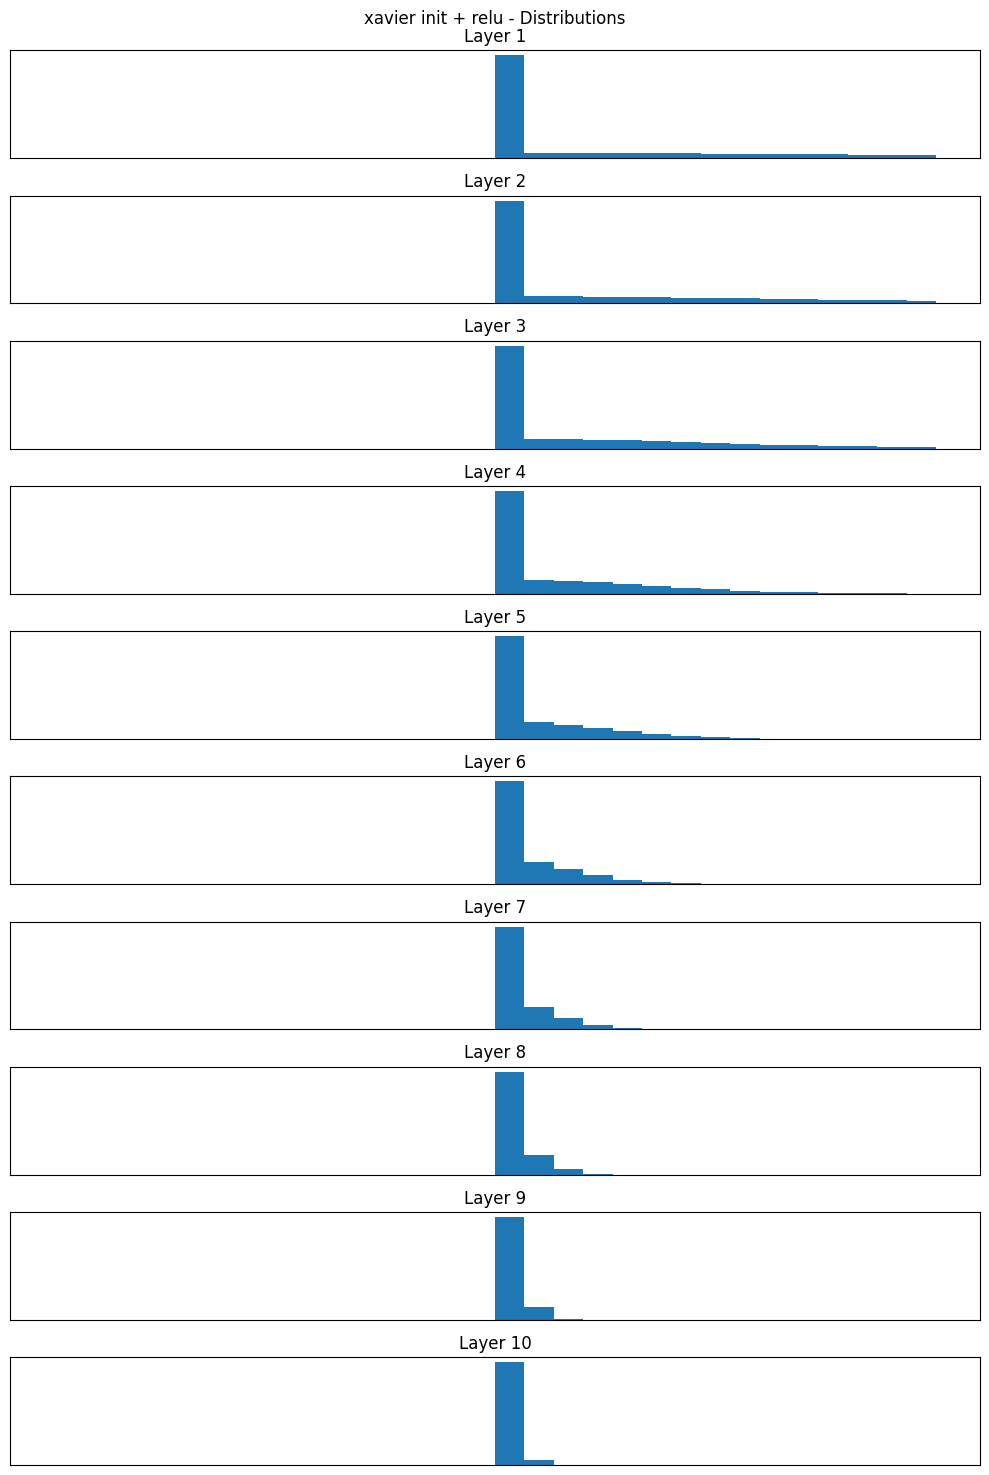

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
D = 500  # Input size (number of features)
N = 1000 # Number of examples (samples)
hidden_layer_sizes = [500] * 10  # 10 hidden layers, each with 500 neurons
nonlinearities = ['relu']  # Activation function (you can add more if needed)

# Activation Functions
act_funcs = {
    'relu': lambda x: np.maximum(0, x),  # ReLU activation function
    'tanh': lambda x: np.tanh(x)  # Tanh activation function
}

# Weight Initialization Methods
init_methods = {
    'xavier': lambda fan_in, fan_out: np.random.randn(fan_in, fan_out) / np.sqrt(fan_in),  # Xavier initialization
}

# Experiment function to run the model and plot results
def run_and_plot(activation, init_type):
    np.random.seed(0)  # Set seed for reproducibility
    X = np.random.randn(N, D)  # Random input data (N examples, D features)
    Hs = {}  # Dictionary to store activations of each layer
    nonlin = act_funcs[activation]  # Select the activation function based on the input
    init_fn = init_methods[init_type]  # Select weight initialization method

    # Forward pass through each layer
    for i in range(len(hidden_layer_sizes)):
        X = X if i == 0 else Hs[i-1]  # Use input for the first layer, or previous layer activations for others
        fan_in = X.shape[1]  # Number of input units (number of features from the previous layer)
        fan_out = hidden_layer_sizes[i]  # Number of neurons in the current layer
        W = init_fn(fan_in, fan_out)  # Initialize weights using the selected method
        H = X @ W  # Matrix multiplication to get activations
        H = nonlin(H)  # Apply the activation function (ReLU or Tanh)
        Hs[i] = H  # Store the activations of this layer

    # Compute mean and standard deviation of activations for each layer
    layer_means = [np.mean(H) for H in Hs.values()]  # Mean of activations
    layer_stds = [np.std(H) for H in Hs.values()]  # Standard deviation of activations

    # Plot the mean and standard deviation for each layer
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(range(len(Hs)), layer_means, 'ob-')  # Use `range(len(Hs))` for correct indexing of layers
    plt.title(f'{init_type} init + {activation} - Layer Means')

    plt.subplot(1, 2, 2)
    plt.plot(range(len(Hs)), layer_stds, 'or-')  # Same here for standard deviation
    plt.title(f'{init_type} init + {activation} - Layer Stds')
    plt.show()

    # Plot histograms for activations in each layer
    plt.figure(figsize=(10, 15))
    for i, H in Hs.items():
        plt.subplot(len(Hs), 1, i + 1)
        plt.hist(H.ravel(), bins=30, range=(-1, 1))  # Plot histograms of activations for each layer
        plt.title(f'Layer {i+1}')
        plt.xticks([])  # Remove x-axis ticks
        plt.yticks([])  # Remove y-axis ticks
    plt.suptitle(f'{init_type} init + {activation} - Distributions')  # Main title
    plt.tight_layout()  # Adjust layout to prevent overlap
    plt.show()

# -------------------
# Experiments
# -------------------
run_and_plot('relu', 'xavier')  # Run the experiment with Xavier initialization and ReLU activation
